<center>
    <h1>Train and use <a style="color:red;">QM</a>Learn for AIMD and optimizations</h1>
    
    Pavanello Research Group
    
    August 2024
    
    MolSSI Workshop @ Buffalo
</center>
 


## `db2qmmodel` is `QM`Learn's shortcut to almost everything
 - use only after you reach `pro` stage and want to save time
 - now commented out 

In [1]:
#from qmlearn.io.model import db2qmmodel
#qmmodel = db2qmmodel('./h2o_data.hdf5', names = 'rks')
#calc = QMLCalculator(qmmodel = qmmodel, method = 'gamma')
# go on with ASE stuff...

## `QM`Learn imports

In [2]:
from qmlearn.drivers.mol import QMMol
from qmlearn.io.hdf5 import DBHDF5

/Users/michele/Documents/Buffalo/qml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/michele/Documents/Buffalo/qml/lib/python3.10/site-packages/pyscf/dft/libxc.py:772: UserWarning: Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, the same to the B3LYP functional in Gaussian and ORCA (issue 1480). To restore the VWN5 definition, you can put the setting "B3LYP_WITH_VWN5 = True" in pyscf_conf.py
  warnings.warn('Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, '


## Read the DB

In [3]:
from qmlearn.io import read_db
rks_db = read_db('h2o_data.hdf5',names='rks')

Guess DB names : {'qmmol': 'rks/qmmol', 'atoms': 'rks/train_atoms_27', 'properties': 'rks/train_props_27'}


In [4]:
refqmmol = rks_db['qmmol']
properties = rks_db['properties']

In [5]:
nao = refqmmol.engine.nao

### `X` and `y` for regression

In [6]:
X = properties['vext']
y = properties['gamma']

### List of models to be considered by `QM`Learn
 - these are already implemented in the `QMModel` class

In [7]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression
mmodels={
    'gamma': KernelRidge(kernel='rbf',alpha=0.0),
    'd_gamma': LinearRegression(),
    'd_energy': LinearRegression(),
    'd_forces': LinearRegression(),
}

In [8]:
from qmlearn.model import QMModel

In [9]:
model = QMModel(mmodels=mmodels, refqmmol = refqmmol)
model.fit(X,y,method='gamma')

KernelRidge(alpha=0.0, kernel='rbf')

In [10]:
model.fit(X,y,method='d_gamma')

LinearRegression()

### Get a "random" water geometry not in the training set

In [75]:
from ase.build import molecule
atoms = molecule('H2O')
atoms.positions*=0.95
qmmol=model.refqmmol.duplicate(atoms)

### Predict $\hat\gamma$ and compare to `exact` one from DFT

In [76]:
gamma = model.predict(qmmol).reshape((nao,nao))
dgamma = model.predict(qmmol,method='d_gamma').reshape((nao,nao))
gamma_exact=qmmol.engine.gamma
err_dg = (qmmol.calc_etotal(dgamma)-qmmol.calc_etotal(gamma_exact))*27.211
err_g = (qmmol.calc_etotal(gamma)-qmmol.calc_etotal(gamma_exact))*27.211
print ("Error (gamma):  ", err_g)
print ("Error (d_gamma):", err_dg)

Error (gamma):   2.594801872771244
Error (d_gamma): 0.03486226505594361


### Train for energies and forces, $E[\hat\gamma]$ (optional)

In [77]:
model.fit(properties['gamma'], properties['energy'], method = 'd_energy')
model.fit(properties['gamma'], properties['forces'], method = 'd_forces');

### Check it is also quite good

In [78]:
err_de = (model.predict(gamma, method='d_energy')-qmmol.engine.calc_etotal(gamma_exact))*27.211
print ("Error (d_energy):", err_de)

Error (d_energy): 0.3325710698836463


### How good is $\hat\gamma[v_{ext}]$?

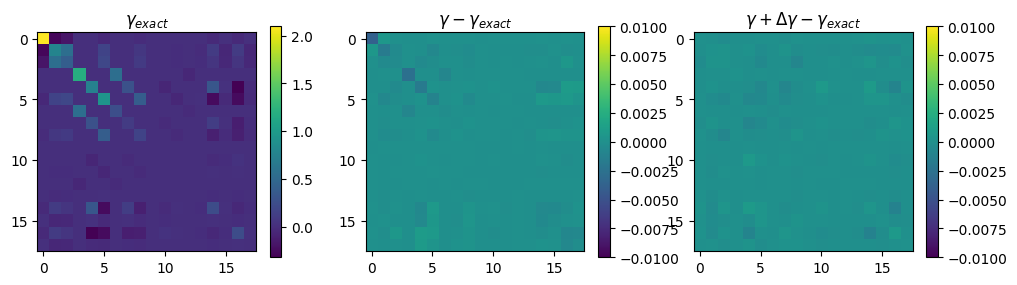

In [79]:
import matplotlib.pyplot as plt 
fig, axs = plt.subplots(1,3,figsize=(12,3))
im0 = axs[0].imshow(gamma_exact)
im1 = axs[1].imshow(gamma-gamma_exact, vmin=-1E-2, vmax=1E-2)
im2= axs[2].imshow(dgamma-gamma_exact, vmin=-1E-2, vmax=1E-2)
axs[0].set_title(r'$\gamma_{exact}$')
axs[1].set_title(r'$\gamma-\gamma_{exact}$')
axs[2].set_title(r'$\gamma+\Delta\gamma-\gamma_{exact}$')
plt.colorbar(im0, ax=axs[0])
plt.colorbar(im1, ax=axs[1])
plt.colorbar(im2, ax=axs[2])
#fig.tight_layout()

# Let's run geometry optimizations!

In [16]:
from ase.optimize import LBFGS 

### `QMLCalculator` is a subclass of the `ASE` calculator class

In [17]:
from qmlearn.api.api4ase import QMLCalculator 

### `method=engine` will use the original QM method

In [18]:
calc = QMLCalculator(qmmodel = model, method = 'engine')

## Optimization and AIMD:

In [19]:
N_aimd = 50 # number of AIMD steps

In [20]:
!rm *.traj *.log

zsh:1: no matches found: *.traj


### Let's start from a water molecule far away from the training set

In [21]:
atoms=molecule('H2O')
atoms.positions[0,0] += 0.2
atoms.calc = calc

In [22]:
LBFGS(atoms, trajectory = 'obj.traj').run(fmax=0.01)
atoms.get_all_distances() 

       Step     Time          Energy         fmax
LBFGS:    0 14:07:54    -2340.853337       17.3877
LBFGS:    1 14:07:55    -2343.873721       10.6101
LBFGS:    2 14:07:55    -2344.186461        5.4470
LBFGS:    3 14:07:56    -2344.431160        1.6937
LBFGS:    4 14:07:56    -2344.470989        0.9514
LBFGS:    5 14:07:57    -2344.480176        0.3337
LBFGS:    6 14:07:57    -2344.480984        0.0211
LBFGS:    7 14:07:58    -2344.480987        0.0004


array([[0.        , 0.7804574 , 0.7804574 ],
       [0.7804574 , 0.        , 1.27733881],
       [0.7804574 , 1.27733881, 0.        ]])

In [23]:
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, force_temperature
from ase.md.verlet import VelocityVerlet
from ase import units

T=300

MaxwellBoltzmannDistribution(atoms, temperature_K = T, force_temp=True)
p = atoms.get_momenta()
c = p.sum(axis = 0)
p -= c/len(atoms)
atoms.set_momenta(p)
force_temperature(atoms, T)

atoms_initial = atoms.copy()

In [24]:
dyn = VelocityVerlet(atoms, timestep=0.8*units.fs, trajectory='md_nve_engine.traj', logfile='md_nve_engine.log')
%timeit -n 1 -r 1 dyn.run(N_aimd)

28.2 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### Now, let's compare convergence and final structure with `QM`Learn's methods

### We start with `gamma+d_gamma`

In [25]:
atoms=molecule('H2O')
atoms.positions[0,0] += 0.2
calc = QMLCalculator(qmmodel = model, method = 'gamma')
atoms.calc = calc

In [26]:
LBFGS(atoms, trajectory = 'obt.traj').run(fmax=0.01)
atoms.get_all_distances() 

       Step     Time          Energy         fmax
LBFGS:    0 14:08:27    -2340.852523       17.8243
LBFGS:    1 14:08:27    -2343.925480       10.1346
LBFGS:    2 14:08:28    -2344.210375        5.4747
LBFGS:    3 14:08:28    -2344.432419        1.9442
LBFGS:    4 14:08:28    -2344.438832        3.8125
LBFGS:    5 14:08:29    -2344.458416        2.6253
LBFGS:    6 14:08:29    -2344.480055        0.4103
LBFGS:    7 14:08:29    -2344.480985        0.0416
LBFGS:    8 14:08:30    -2344.480992        0.0026


array([[0.        , 0.78044394, 0.78045749],
       [0.78044394, 0.        , 1.27737049],
       [0.78045749, 1.27737049, 0.        ]])

In [27]:
atoms = atoms_initial.copy()
atoms.calc = calc

dyn = VelocityVerlet(atoms, timestep=0.8*units.fs, trajectory='md_nve_gamma.traj', logfile='md_nve_gamma.log')
%timeit  -n 1 -r 1  dyn.run(N_aimd)

16.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### Now we employ `d_energy`

In [28]:
atoms=molecule('H2O')
atoms.positions[0,0] += 0.2

second_learn = {
            'energy' : 'd_energy',
            'forces' : 'd_forces',
            }

calc = QMLCalculator(qmmodel = model, second_learn=second_learn, method = 'gamma')

atoms.calc = calc

In [29]:
LBFGS(atoms, trajectory = 'obt.traj').run(fmax=0.01)
atoms.get_all_distances() 

       Step     Time          Energy         fmax
LBFGS:    0 14:08:46    -2341.128896       17.7687
LBFGS:    1 14:08:46    -2343.804242       11.6457
LBFGS:    2 14:08:47    -2344.179828        6.0591
LBFGS:    3 14:08:47    -2344.428631        2.4616
LBFGS:    4 14:08:47    -2344.342630        7.4279
LBFGS:    5 14:08:47    -2344.475371        1.1420
LBFGS:    6 14:08:47    -2344.480045        0.2714
LBFGS:    7 14:08:47    -2344.480935        0.0446
LBFGS:    8 14:08:47    -2344.480989        0.0052


array([[0.        , 0.78042481, 0.78046369],
       [0.78042481, 0.        , 1.2773412 ],
       [0.78046369, 1.2773412 , 0.        ]])

In [30]:
atoms = atoms_initial.copy()
atoms.calc = calc

dyn = VelocityVerlet(atoms, timestep=0.8*units.fs, trajectory='md_nve_de.traj', logfile='md_nve_de.log')
%timeit  -n 1 -r 1 dyn.run(N_aimd)

3.38 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


## Let's check the trajectories are comparable (or close to identical)

In [31]:
from ase.visualize import view
from ase.io.trajectory import read_traj, TrajectoryReader

In [32]:
tr_engine = TrajectoryReader('./md_nve_engine.traj',)
tr_gamma = TrajectoryReader('./md_nve_gamma.traj')
tr_de = TrajectoryReader('./md_nve_de.traj')

In [33]:
from qmlearn.preprocessing import atoms_rmsd

In [34]:
for i in range(N_aimd):
    print("RMSD(gamma): %5.4f, RMSD(d_energy): %5.4f" % (atoms_rmsd(tr_engine[i],tr_gamma[i])[0], atoms_rmsd(tr_engine[i],tr_de[i])[0]))

RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0000, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0000
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0002
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0001, RMSD(d_energy): 0.0001
RMSD(gamma): 0.0000, RMSD(d_ener